---
**Name : Aashoday S Surwade**\
**Roll No : 24AI126**\
**Class : SE-B AIML**\
**Course : FML**\
**FML Assignment 8**

---

**Problem Statement** :

Implement assignment based on K-Medoid clustering algorithm
and evaluate the performance

*Case Study* : Telecommunication Customer Plan Grouping: To
segment telecom customers into meaningful clusters based on their
usage behavior, such as call duration, data consumption, and text
message usage. This segmentation helps telecom companies
design personalized plans and offers.

---

In [1]:
# Import libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

In [2]:
# load dataset
df = pd.read_csv("data/Telco-Customer-Churn.csv")

print("Dataset shape:", df.shape)
df.head()

Dataset shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
# Drop customer id
df = df.drop("customerID", axis=1)

# Fix TotalCharges column (convert to numeric)
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop missing values
df = df.dropna()

print("Shape after cleaning:", df.shape)

df.dtypes

Shape after cleaning: (7032, 20)


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object

In [4]:
# Select clustering features
features = ["tenure", "MonthlyCharges", "TotalCharges"]

X = df[features]

print("Selected features shape: ", X.shape)
X.head()

Selected features shape:  (7032, 3)


,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [5]:
# Feature Scaling 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled Shape: ", X_scaled.shape)

Scaled Shape:  (7032, 3)


In [6]:
# Silhouette score for K-Medoids

from sklearn_extra.cluster import KMedoids
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2, 8):
    kmedoids = KMedoids(n_clusters=k, random_state=42, method="pam")
    labels = kmedoids.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    sil_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

K = 2, Silhouette Score = 0.4794
K = 3, Silhouette Score = 0.4449
K = 4, Silhouette Score = 0.4721
K = 5, Silhouette Score = 0.4438
K = 6, Silhouette Score = 0.4304
K = 7, Silhouette Score = 0.4295


In [7]:
# K-Medoids model
kmedoids = KMedoids(n_clusters=2, random_state=42, method="pam")
clusters = kmedoids.fit_predict(X_scaled)

df["cluster"] = clusters

print("Clustering Complete")
df["cluster"].value_counts()

Clustering Complete


cluster
0    4665
1    2367
Name: count, dtype: int64

In [8]:
# Compare cluster-wise avg
cluster_summary = df.groupby("cluster")[["tenure", "MonthlyCharges", "TotalCharges"]].mean()

cluster_summary

,tenure,MonthlyCharges,TotalCharges
cluster,,,
0,19.938264,52.343558,864.738221
1,57.024926,89.344444,5079.072624


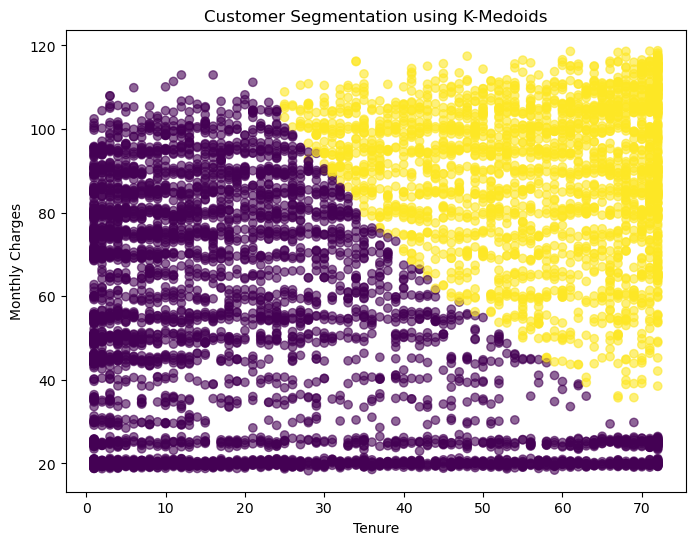

In [9]:
# CLuster visualization (2D scatter)
plt.figure(figsize=(8,6))

plt.scatter(df["tenure"], df["MonthlyCharges"],
            c=df["cluster"], cmap="viridis", alpha=0.6)

plt.xlabel("Tenure")
plt.ylabel("Monthly Charges")
plt.title("Customer Segmentation using K-Medoids")
plt.show()

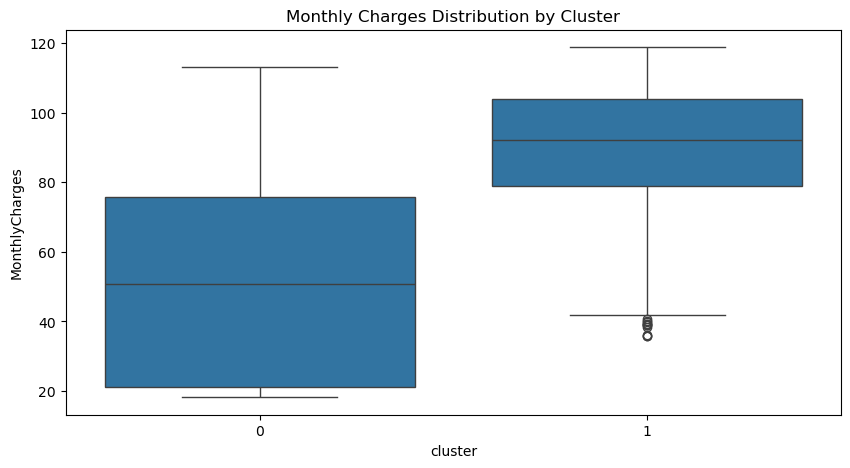

In [10]:
# Box plot visualization
plt.figure(figsize=(10,5))

sns.boxplot(x="cluster", y="MonthlyCharges", data=df)
plt.title("Monthly Charges Distribution by Cluster")
plt.show()

In [11]:
# Final silhouette score
final_score = silhouette_score(X_scaled, df["cluster"])
print("Final silhouette score: ", round(final_score, 4))

Final silhouette score:  0.4794


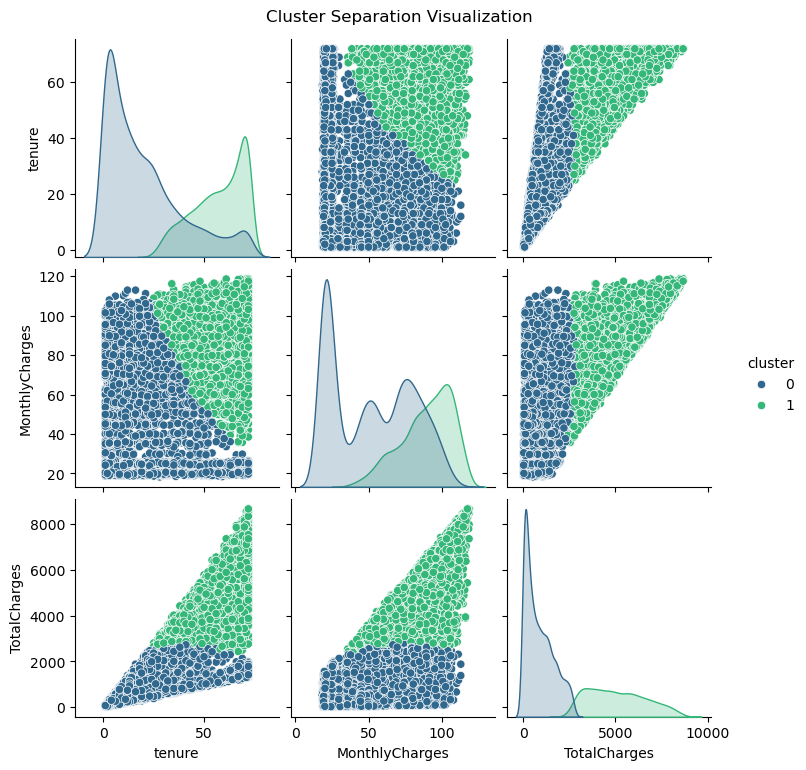

In [13]:
# Pairplot visualizatio
sns.pairplot(df,
             vars=["tenure", "MonthlyCharges", "TotalCharges"],
             hue="cluster",
             palette="viridis",
             diag_kind="kde")

plt.suptitle("Cluster Separation Visualization", y=1.02)
plt.show()

---
### Conclusion: 


---